<a href="https://colab.research.google.com/github/jaroslav200720072007-beep/cifar10-image-classification-pytorch/blob/main/%D1%83%D1%80%D0%BE%D0%BA_10_%D0%9D%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D1%96_%D0%9C%D0%B5%D1%80%D0%B5%D0%B6%D1%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Нейромережі
PyTorch
Класифікація зображень мультиклосова

In [133]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm import tqdm ##Щоб слідкувати за процесом навчання

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [134]:
train_transforms = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),  # Випадкове віддзеркалення
        transforms.RandomCrop(32, padding=4),  # Зсуви картинки
        transforms.ToTensor(),
    ]
)

train_dataset = torchvision.datasets.CIFAR10(
    root="/content", train=True, transform=train_transforms, download=True
)

# Для валідаційного датасету залишаємо тільки ToTensor
valid_dataset = torchvision.datasets.CIFAR10(
    root="/content",
    train=False,
    transform=transforms.ToTensor(),
    download=True,
)

In [135]:
train_dataset.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [136]:
len(train_dataset), len(valid_dataset)

(50000, 10000)

In [137]:
img, label = train_dataset[0]

Це frog


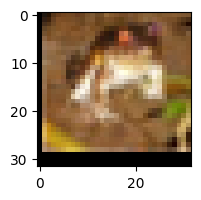

In [138]:
plt.figure(figsize=(2, 2))
print(f"Це {train_dataset.classes[label]}")
plt.imshow(img.permute(1, 2, 0))

In [139]:
##В pytorch є основні класи DataLoader, Dataset класи без яких неможемо навчати модель
##Спочатку дані опрацьовані мають бути Dataset а потім DataLoader
##DataLoader розглядаємо
##Dataset можемо нерозглядати так як завантажали дата сет від torch
type(train_dataset)
len(train_dataset)
train_dataset[100][1] ##це клас 8 а 8 клас це кінь
##1 це обєкт зображення другий це клас

8

In [140]:
train_loader = DataLoader(
    train_dataset,
    batch_size = 64, ##64 обэкти будуть повертатися
    shuffle = True,
    drop_last = True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size = 64,
    shuffle = True,
    drop_last = True
)

In [141]:
imeges, target = next(iter(train_loader))

print(imeges.shape, target.shape)

torch.Size([64, 3, 32, 32]) torch.Size([64])


In [142]:
##Архітектура Нейроної Мережі
##Нам треба обовязково метод forward і для цього треба наслідувати nn.Module шоб розуміти зворотнє поши рення помилки
class Net(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(input_size, hidden_size),
        nn.BatchNorm1d(hidden_size), ##спеціальний шар нейромережі, який нормалізує (приводить до єдиного масштабу, щоб розподілення було нормальне) виходи попереднього шару для кожного батчу даних, нормалізація як в класичному
        nn.ReLU(), ##Якщо значення менше 0 воно зануляєця

        nn.Linear(hidden_size, hidden_size*2),
        nn.BatchNorm1d(hidden_size*2),
        nn.ReLU(),

        nn.Linear(hidden_size*2, hidden_size),
        nn.BatchNorm1d(hidden_size),
        nn.ReLU(),


        nn.Linear(hidden_size, output_size) ##10 класів

     )


  def forward(self, x):
      x = x.view(x.size(0), -1)
      return self.model(x)

In [143]:
model = Net(
    input_size = (3 * 32 * 32),
    hidden_size = 256,
    output_size = len(train_dataset.classes)
).to(device) ##Кладемо модель на cpu
print(sum([param.numel() for param in model.parameters()]))

1054218


In [144]:
next(model.parameters()).device

device(type='cpu')

In [145]:
criterion = nn.CrossEntropyLoss() ##softmax() тут в CrossEntropyLoss для того щоб штрафувати модель за те що вона дає високі ймовірності відміні від 0 тим класам які неє насправді
optimizator = torch.optim.Adam(model.parameters(), lr = 1e-3)

In [146]:
def train(loader):
  model.train() ##Режим тренування та оновлення градієнтів
  total_loss = 0
  total_accuracy = 0

  ##ітеруємося по loader
  for batch in tqdm(loader):
    optimizator.zero_grad() ##Градієнти мають чиститися
##картинки, класи
    src, tgt = batch[0].to(device), batch[1].to(device) ##Дані перекладаємо на дивайс
    ##подаємо в модель наші картинки
    outputs = model(src)
    loss = criterion(outputs, tgt) ##Рахуємо помилку від стпрогнозованих класів та тих класів дійсних які вони є

    total_loss += loss.item() ##Плюсуємо loss
    loss.backward() ##ідемо назад по полилці
    optimizator.step() ##робимо градієнти і крок

    predict_labels = torch.argmax(outputs, dim=1) ##argmax беремо по розміру логітів

    accuracy = (predict_labels == tgt).float().mean() * 100
    total_accuracy += accuracy.item()

  return total_loss / len(loader), total_accuracy / len(loader)



def evalute(loader):
    model.eval()  ##Переведення в стан інференсу каже нам ця вибірка леше для оцінки
    total_loss = 0
    total_accuracy = 0

    with torch.no_grad():  ##Обгортка шоб точно нерахувалися градієнти
        for (
            batch
        ) in tqdm(
            loader
        ):  ##Робимо те саме тікі не рахуємо ніяких градієнтів

            src, tgt = batch[0].to(device), batch[1].to(device)

            outputs = model(src)
            loss = criterion(outputs, tgt)
            total_loss += loss.item()  ##Плюсуємо loss
            predict_labels = torch.argmax(
                outputs, dim=1
            )  ##argmax беремо по розміру логітів

            accuracy = (predict_labels == tgt).float().mean() * 100
            total_accuracy += accuracy.item()

    return total_loss / len(loader), total_accuracy / len(loader)

In [148]:
epochs = 20 ##Одна епоха це прохід по 10 раз по всіх даних і на кожній епосі ми 1 раз пройдемося тренуванням і оновили градієнти і 10 треін і 10 валідаційних після траін циклі
##На cpu має бути і одель і наші дані
for epoch in range(epochs):
  loss, acc = train(train_loader)
  val_loss, val_acc = evalute(valid_loader)

  print(f"epoch: {epoch + 1} | loss: {loss:.3f} | accuracy: {acc:.3f} | val_loss: {val_loss:.3f} | val_accuracy: {val_acc:.3f}")

  ##Ми бачімо процес навчання бо loader абгорнули в tqdm

100%|██████████| 156/156 [00:03<00:00, 49.20it/s]


epoch: 1 | loss: 1.671 | accuracy: 39.439 | val_loss: 1.585 | val_accuracy: 42.518


100%|██████████| 156/156 [00:02<00:00, 71.25it/s]


epoch: 2 | loss: 1.575 | accuracy: 42.892 | val_loss: 1.501 | val_accuracy: 45.863


100%|██████████| 156/156 [00:02<00:00, 55.09it/s]


...

epoch: 18 | loss: 1.236 | accuracy: 55.626 | val_loss: 1.222 | val_accuracy: 56.520


100%|██████████| 156/156 [00:02<00:00, 72.80it/s]


epoch: 19 | loss: 1.219 | accuracy: 56.184 | val_loss: 1.215 | val_accuracy: 57.332


100%|██████████| 156/156 [00:02<00:00, 58.32it/s]

epoch: 20 | loss: 1.216 | accuracy: 56.218 | val_loss: 1.216 | val_accuracy: 57.302


In [149]:
##Зберігання моделі після навчання
##Зберігаємо ваги навченої моделі
torch.save(model.state_dict(), "/content/cifar_model.pth")  ##Метод який поаертає ваги моделі state_dict()

In [150]:
##Заново підгрузим бо ми завантажили леше ваги тоді заініціалізуємо заново модель
model = Net( input_size = (3 * 32 * 32),
            hidden_size = 256,
            output_size= len(train_dataset.classes)).to(device)
model.load_state_dict(torch.load("/content/cifar_model.pth", map_location= "cpu"))

<All keys matched successfully>

['frog', 'automobile', 'airplane', 'cat', 'bird', 'frog', 'truck', 'deer']


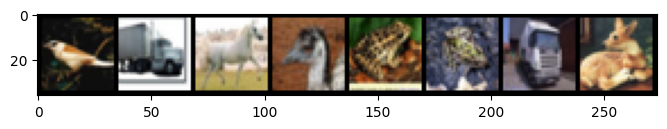

In [151]:
model.eval()


with torch.no_grad():
  valid_images, _ = next(iter(valid_loader))
  outputs = model(valid_images.to(device))[:8]
  labels = torch.argmax(outputs, dim=1).tolist()

  grid = torchvision.utils.make_grid(valid_images[:8])
  print([valid_dataset.classes[i] for i in labels])

  plt.figure(figsize=(8, 5))
  plt.imshow(grid.permute(1, 2, 0))
  plt.show()